In [2]:
import pandas as pd

# Load CSV (replace with actual path)
df = pd.read_excel("../Bearing Dataset July 2025.xlsx")

# Strip whitespace and lowercase column names for consistency
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Preview the dataset
df.head()


,unnamed:_0,bearing_type_assigned_1,bearing_type_assigned_2,bearing_type_assigned_3,bearing_make,industry_type,lubrication_method,monitor_id,subscription_start,subscription_end,machine_type,speed_type,rpm_min,rpm_max,timestamp_of_fault,bearing_severity_class
0,0,Bearing_1,NaN,NaN,MAKE_1,INDUSTRY_1,Not Available,11781,2021-02-01,NaN,Fan - Centrifugal Fan(Single Suction),VARIABLE,2350.0,2550.0,2021-06-23 15:56:54.000,0
1,1,Bearing_2,NaN,NaN,MAKE_2,INDUSTRY_2,Not Available,17974,2021-05-18,NaN,Gearbox - Helical Gearbox,VARIABLE,12.0,23.0,2021-11-16 11:42:25.000,0
2,2,Bearing_3,NaN,NaN,MAKE_1,INDUSTRY_1,Not Available,29078,2021-09-29,NaN,Fan - Over Hung Fan,FIXED,1500.0,1500.0,2021-12-29 05:09:41.963,0
3,3,Bearing_4,NaN,NaN,MAKE_1,INDUSTRY_1,Not Available,19570,2021-06-01,NaN,Gearbox - Helical Gearbox,VARIABLE,780.0,900.0,2022-01-18 05:05:15.000,0
4,4,Bearing_4,NaN,NaN,MAKE_1,INDUSTRY_1,Not Available,19561,2021-06-01,NaN,Gearbox - Helical Gearbox,VARIABLE,600.0,900.0,2022-01-18 09:45:03.924,0


In [3]:
# Check shape and missing values
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7403 entries, 0 to 7402
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   unnamed:_0               7403 non-null   int64  
 1   bearing_type_assigned_1  6196 non-null   object 
 2   bearing_type_assigned_2  118 non-null    object 
 3   bearing_type_assigned_3  8 non-null      object 
 4   bearing_make             6196 non-null   object 
 5   industry_type            7085 non-null   object 
 6   lubrication_method       7403 non-null   object 
 7   monitor_id               7403 non-null   int64  
 8   subscription_start       7272 non-null   object 
 9   subscription_end         0 non-null      float64
 10  machine_type             7295 non-null   object 
 11  speed_type               7385 non-null   object 
 12  rpm_min                  7385 non-null   float64
 13  rpm_max                  7385 non-null   float64
 14  timestamp_of_fault      

unnamed:_0                    0
bearing_type_assigned_1    1207
bearing_type_assigned_2    7285
bearing_type_assigned_3    7395
bearing_make               1207
industry_type               318
lubrication_method            0
monitor_id                    0
subscription_start          131
subscription_end           7403
machine_type                108
speed_type                   18
rpm_min                      18
rpm_max                      18
timestamp_of_fault            0
bearing_severity_class        0
dtype: int64

In [4]:
# Convert dates to datetime
df['timestamp_of_fault'] = pd.to_datetime(df['timestamp_of_fault'], errors='coerce')
df['subscription_start'] = pd.to_datetime(df['subscription_start'], errors='coerce')

# Fill bearing_type from assigned_1 to 3 (first non-null)
df['bearing_type'] = df[['bearing_type_assigned_1', 'bearing_type_assigned_2', 'bearing_type_assigned_3']]\
                        .bfill(axis=1).iloc[:, 0]

# Operational Life in Days
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days

# Fill missing severity
df['severity'] = df['bearing_severity_class'].fillna(0).astype(int)

# Normalize categorical text
df['lubrication_method'] = df['lubrication_method'].fillna("Not Available")


In [5]:
df_clean = df.dropna(subset=['bearing_type_assigned_1', 'bearing_make', 'industry_type'])


In [6]:
df['bearing_make'].value_counts()
df['bearing_type'].value_counts()


bearing_type
Bearing_12     231
Bearing_3      201
Bearing_13     155
Bearing_341    151
Bearing_49     143
              ... 
Bearing_596      1
Bearing_597      1
Bearing_599      1
Bearing_602      1
Bearing_378      1
Name: count, Length: 754, dtype: int64

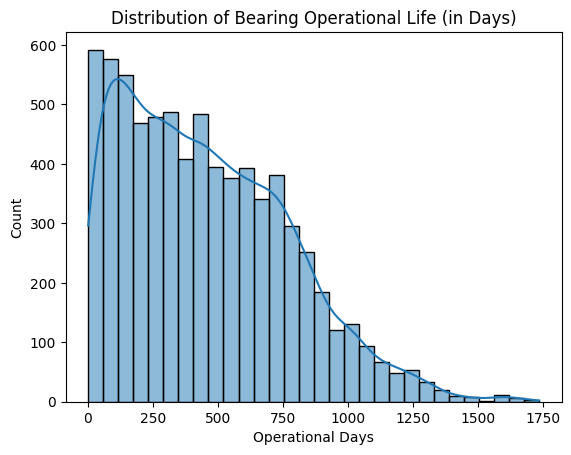

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['operational_days'].dropna(), bins=30, kde=True)
plt.title("Distribution of Bearing Operational Life (in Days)")
plt.xlabel("Operational Days")
plt.ylabel("Count")
plt.show()


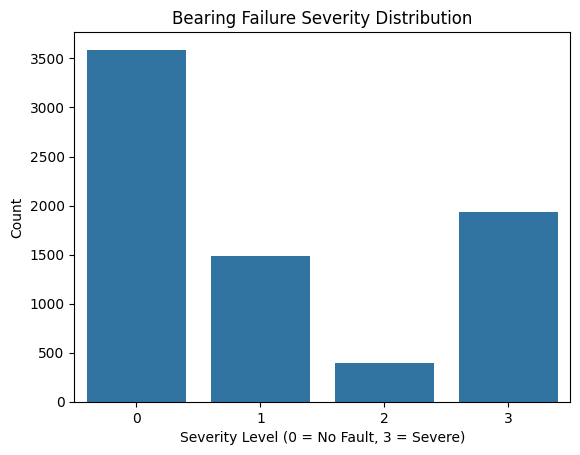

In [8]:
sns.countplot(data=df, x='severity')
plt.title("Bearing Failure Severity Distribution")
plt.xlabel("Severity Level (0 = No Fault, 3 = Severe)")
plt.ylabel("Count")
plt.show()


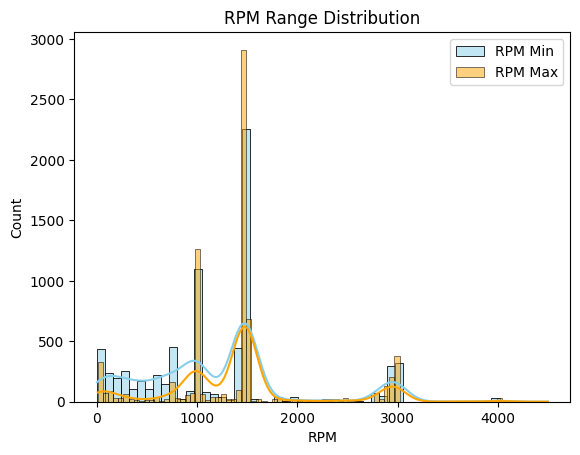

In [9]:
sns.histplot(df['rpm_min'], color="skyblue", label="RPM Min", kde=True)
sns.histplot(df['rpm_max'], color="orange", label="RPM Max", kde=True)
plt.title("RPM Range Distribution")
plt.xlabel("RPM")
plt.legend()
plt.show()


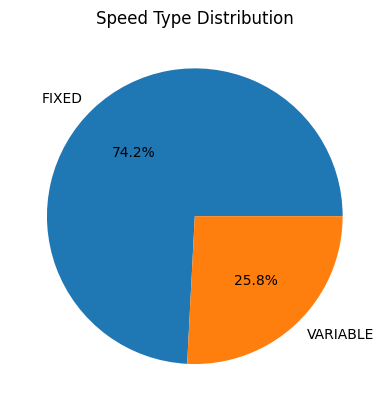

In [10]:
df['speed_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Speed Type Distribution")
plt.ylabel("")
plt.show()


In [11]:
df.to_csv("cleaned_bearing_data.csv", index=False)
